used vit in reference to classification

In [ ]:
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch.utils.data as dataloader

# Data Ingestion

In [ ]:
# transformation for PIL->TENSOR

transformation_operation=torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

In [ ]:
# importing dataset
train_dataset= torchvision.datasets.MNIST(root="./data",train=True,download=True,transform=transformation_operation)

test_dataset= torchvision.datasets.MNIST(root="./data",train=False,download=True,transform=transformation_operation)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.67MB/s]


In [ ]:
num_classes=10
batch_size=64
num_channels=1
image_size=28
patch_size=7
num_patches=(image_size//patch_size)**2
embedding_dim=64

attention_heads=4
mlp_hidden_nodes=128
transformer_blocks=4

learning_rate=0.001
epochs=5

In [ ]:
num_patches

16

In [ ]:
#define batches
train_loader=dataloader.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
val_loader=dataloader.DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

### Part 1 : Patch Embedding

walkthrough

part1 : Patch embedding
part2 : Transformer encoder
part3 : transformer class

In [ ]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed=nn.Conv2d(num_channels,embedding_dim,kernel_size=patch_size,stride=patch_size)
  def forward(self,x):
    #patch embedding
    x=self.patch_embed(x)
    #flatten
    x=x.flatten(2)
    # making it [64,16,64]
    x=x.transpose(1,2)
    return x

### Transformer encoder


In [22]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1_norm1=nn.LayerNorm(embedding_dim)
    self.layer2_norm2=nn.LayerNorm(embedding_dim)
    self.multihead_attention=nn.MultiheadAttention(embedding_dim,attention_heads,batch_first=True)
    self.mlp=nn.Sequential(
        nn.Linear(embedding_dim,mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes,embedding_dim)
    )
  def forward(self,x):
    res1=x
    x=self.layer1_norm1(x)
    x, _ = self.multihead_attention(x, x, x)
    x = x + res1

    res2=x
    x=self.layer2_norm2(x)
    x=self.mlp(x)
    x=x+res2

    return x

In [23]:
# part 3

# mlp head


class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(embedding_dim)
    self.mlp_head=nn.Linear(embedding_dim,num_classes)
  def forward(self,x):
    x=self.layer_norm1(x)
    x=self.mlp_head(x)

    return x

main class


In [24]:
import torch

In [25]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding=PatchEmbedding()
    #cls token -> position embedding
    # cls token passed to mlp head
    self.cls_token= nn.Parameter(torch.randn(1,1,embedding_dim))
    self.position_embedding=nn.Parameter(torch.randn(1,1+num_patches,embedding_dim))
    self.transformer_blocks=nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head=MLP_head()
  def forward(self,x):
    x=self.patch_embedding(x)
    B=x.size(0)

    cls_=self.cls_token.expand(B,-1,-1)
    x=torch.cat((cls_,x),dim=1)
    x=x+self.position_embedding
    x=self.transformer_blocks(x)
    x=x[:,0]
    x=self.mlp_head(x)
    return x


In [26]:
device=torch.device('cuda') if torch.cuda.is_available() else 'cpu'
model= VisionTransformer().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
criterion=nn.CrossEntropyLoss()

In [27]:
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True) # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    accuracy = 100. * correct / len(val_loader.dataset)

    print(f'Epoch: {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%')

print("Training complete!")

Epoch: 1/5, Train Loss: 0.3632, Val Loss: 0.1402, Accuracy: 95.95%
Epoch: 2/5, Train Loss: 0.1248, Val Loss: 0.1149, Accuracy: 96.61%
Epoch: 3/5, Train Loss: 0.0917, Val Loss: 0.0897, Accuracy: 97.27%
Epoch: 4/5, Train Loss: 0.0714, Val Loss: 0.0991, Accuracy: 97.06%
Epoch: 5/5, Train Loss: 0.0637, Val Loss: 0.0689, Accuracy: 97.85%
Training complete!


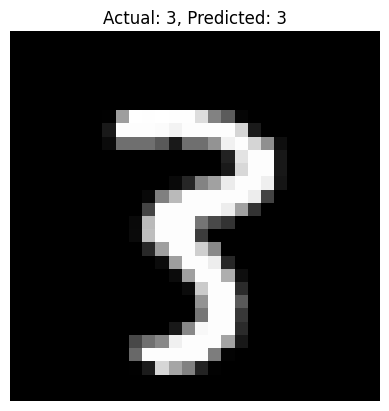

In [29]:
import matplotlib.pyplot as plt

data, target = next(iter(val_loader))
data, target = data.to(device), target.to(device)
model.eval()

with torch.no_grad():

    output = model(data)
    pred = output.argmax(dim=1, keepdim=True)

image_index = 0
single_image = data[image_index].cpu().squeeze().numpy()
single_target = target[image_index].item()
single_prediction = pred[image_index].item()

# Display the image and its prediction
plt.imshow(single_image, cmap='gray')
plt.title(f"Actual: {single_target}, Predicted: {single_prediction}")
plt.axis('off')
plt.show()
